In [ ]:
def wiener_noise_cancel(x, v2, order):
    """
    Wiener noise cancelling: estimate the polluting noise v1 (hidden in x = d + v1)
    from a correlated reference v2, then subtract it to recover the desired signal.
    Wiener-Hopf: R_v2v2 @ w = r_xv2  (the d part vanishes since d and v2 are uncorrelated).

    Inputs
    ------
    x     : (N,) measured signal (desired + pollution: x = d + v1)
    v2    : (N,) noise reference, correlated with v1, uncorrelated with d
    order : (scalar) filter order (order = p-1 => p = order + 1)

    Outputs
    -------
    w : (p,) FIR Wiener coefficients (filter that turns v2 into an estimate of v1)
    """
    p = order + 1
    N = len(x)

    # autocorrelation of the reference v2  -> matrix R_v2v2
    r_v2v2 = np.correlate(v2, v2, mode='full') / N
    R_v2v2 = toeplitz(r_v2v2[N-1 : N-1+p])

    # cross-correlation x with v2  -> vector r_xv2 (equals r_v1v2 since d ⊥ v2)
    r_xv2 = np.correlate(x, v2, mode='full') / N
    r_xv2 = r_xv2[N-1 : N-1+p]

    # solve Wiener-Hopf
    w = np.linalg.solve(R_v2v2, r_xv2)

    return w

# MSE StatDig : Chap 7 "Optimum filter"
## Ex 7.3 FIR Wiener Noise Cancelling
ver : DLY/19.04.2026

## General

### Description

The noise cancellation problem is described by the following figure:

![filter](src/Noise-cancelling-73.png)


Suppose the desired signal d[n] is given by :

$$d[n] = sin(n\omega_0 +\phi)$$

with $\omega_0=0.05\pi$ and the related noise sequence $v_1[n]$ and $v_2[n]$ are AR(1) processes driven by the same noise signal $v[n]$.

$$
v_1[n] = 0.8 \, v_1[n - 1] + v[n]
$$

$$
H_1(z) = \frac{1}{1 - 0.8 z^{-1}}
$$

$$
v_2[n] = -0.6 \, v_2[n - 1] + v[n]
$$

$$
H_2(z) = \frac{1}{1 + 0.6 z^{-1}}
$$

Where v[n] is zero-mean, unit variance white noise that is clearly uncorrelated with d[n].
Goal is to design a FIR Wiener filter of orders 5 and 11 to remove the noise.

### Work

#### Ex1 : Signal generation

- Display the signals created by the following code :

```python
worders = [5,11] # filter orders
N = 200 # number of sample
phi = np.random.rand()*2*np.pi-np.pi # phase of the signal
n   = np.arange(N)
SigmaN = 1 # std of the noise
H1_a = -0.8 # AR(1) coeff of H1
H2_a = 0.6 # AR(1) coeff of H2

# fix the random seed for reproducibility
np.random.seed(0)

w0 = 0.05*np.pi;
d = np.sin(n*w0+phi);         # Signal without noise
v = SigmaN * np.random.normal(0,1,N)   # source noise


v1 = signal.lfilter(1,[1,H1_a],v) # noise which disturb d[n]
v2 = signal.lfilter(1,[1,H2_a],v)  # noise measured
x  = d+v1;                  # Measured signal
```

In [81]:
import numpy as np
import matplotlib.pyplot as plt 
import sounddevice as sd
import scipy.signal as signal
import numpy.linalg as lin
import scipy.linalg as linalg
from scipy.io import wavfile
from scipy.signal import tf2zpk
from scipy.signal import freqz
from scipy.signal import TransferFunction
from scipy.linalg import toeplitz
import pywt as wt

In [82]:
worders = [5,11] # filter orders
N = 200 # number of sample
phi = np.random.rand()*2*np.pi-np.pi # phase of the signal
n   = np.arange(N)
SigmaN = 1 # std of the noise
H1_a = -0.8 # AR(1) coeff of H1
H2_a = 0.6 # AR(1) coeff of H2

# fix the random seed for reproducibility
np.random.seed(0)

w0 = 0.05*np.pi;
d = np.sin(n*w0+phi);         # Signal without noise
v = SigmaN * np.random.normal(0,1,N)   # source noise


v1 = signal.lfilter(1,[1,H1_a],v) # noise which disturb d[n]
v2 = signal.lfilter(1,[1,H2_a],v)  # noise measured
x  = d+v1;                  # Measured signal

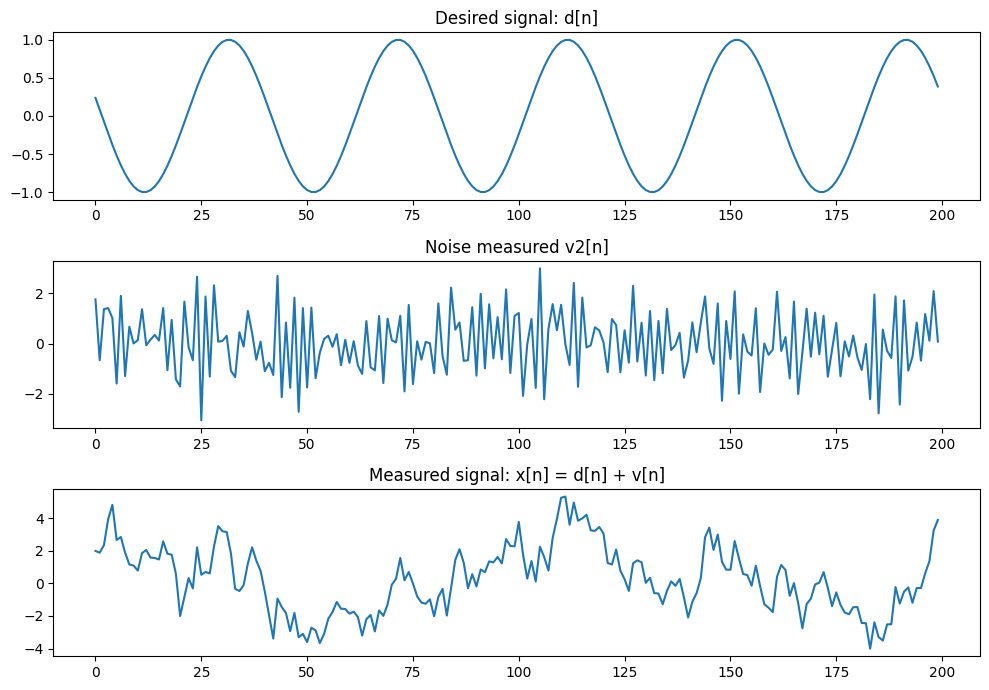

In [83]:
# Plot the signal

fig = plt.figure(figsize=(10, 7))

ax1 = fig.add_subplot(3, 1, 1)      # initialize the top Axes
ax1.plot(d)                      # plot the top graph
plt.title('Desired signal: d[n]')
fig.tight_layout()

ax2 = fig.add_subplot(3, 1, 2)      # initialize the bottom left Axes
ax2.plot(v2)  # plot the bottom left graph
plt.title('Noise measured v2[n]')
fig.tight_layout()

ax3 = fig.add_subplot(3, 1, 3)      # initialize the bottom right Axes
ax3.plot(x)
plt.title('Measured signal: x[n] = d[n] + v[n]')
fig.tight_layout()

#### Ex2 : Wiener solving
##### Ex2.1 Filter design
The Wiener-Hopf equations for the noise cancellation described by figure are given by :

$$
\mathbf{R}_{v_2 v_2} \mathbf{w} = \mathbf{r}_{v_1 v_2}
$$

As we assume that the noise \( $v_2[n]$ \) is uncorrelated with \( $d[n]$ \) :

$$
r_{v_1 v_2}[k] = \mathbb{E} \left\{ v_1[n] v_2^*[n - k] \right\}
= \mathbb{E} \left\{ \left( x[n] - d[n] \right) v_2^*[n - k] \right\}
$$

Then, the Wiener-Hopf equations become:

$$
\mathbf{R}_{v_2 v_2} \mathbf{w} = \mathbf{r}_{x v_2}
$$

And the solution is:

$$
\mathbf{w} = \mathbf{R}_{v_2 v_2}^{-1} \mathbf{r}_{x v_2}
$$

- Compute and display the correlation vectors $r_{v2,v2}$ and $r_{x,v2}$ for each filter order
- Compute and display the filter coefficients for each order


In [84]:
r_full = np.correlate(x, v2, mode='full')
r2_full = np.correlate(v2, v2, mode='full')

#rv2v2 for w = 5
r_v2v2_5 = r2_full[N-1 : N + worders[0]]
R_v2v2_5 = linalg.toeplitz(r_v2v2_5/N)

#rv2v2 for w = 11
r_v2v2_11 = r2_full[N-1 : N + worders[1]]
R_v2v2_11 = linalg.toeplitz(r_v2v2_11/N)

#rx2v2 for w = 5
r_x2v2_5 = r_full[N-1 : N + worders[0]]
r_x2v2_5 = r_x2v2_5/N

#rx2v2 for w = 11
r_x2v2_11 = r_full[N-1 : N + worders[1]]
r_x2v2_11 = r_x2v2_11/N

#w, for w = 5
w_5 = np.linalg.solve(R_v2v2_5, r_x2v2_5)
#w, for w = 5
w_11 = np.linalg.solve(R_v2v2_11, r_x2v2_11)

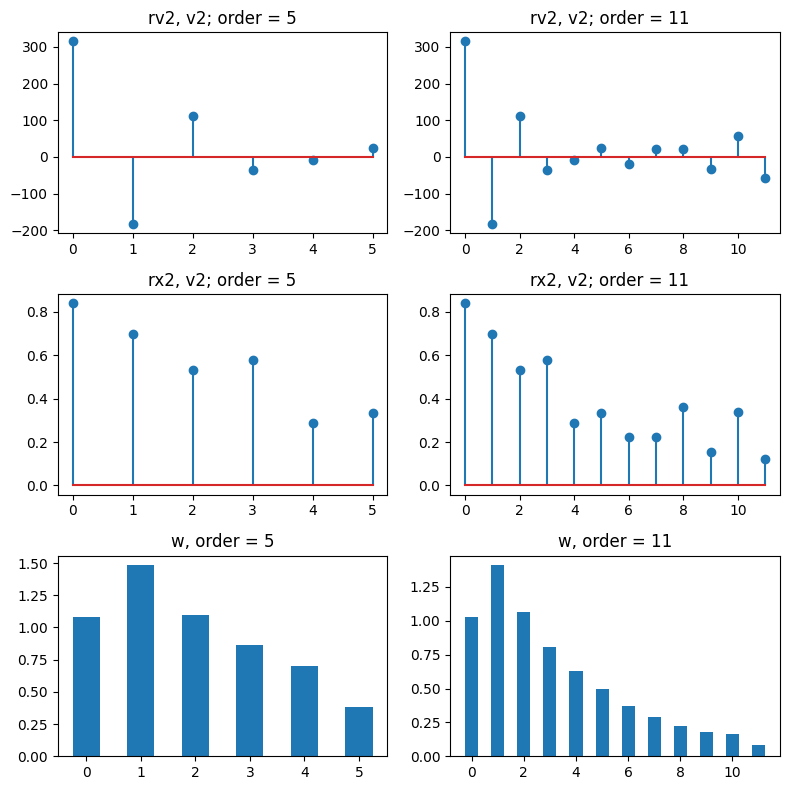

In [85]:
width = 0.5
indices_5 = range(len(w_5))
indices_11 = range(len(w_11))

fig = plt.figure(figsize=(8, 8))

ax1 = fig.add_subplot(3, 2, 1)
ax1.stem(np.arange(len(r_v2v2_5)), r_v2v2_5)
ax1.set_title('rv2, v2; order = 5')
fig.tight_layout()

ax2 = fig.add_subplot(3, 2, 2)
ax2.stem(np.arange(len(r_v2v2_11)), r_v2v2_11)
ax2.set_title('rv2, v2; order = 11  ')
fig.tight_layout()

ax3 = fig.add_subplot(3, 2, 3)
ax3.stem(np.arange(len(r_x2v2_5)), r_x2v2_5)
ax3.set_title('rx2, v2; order = 5')
fig.tight_layout()

ax4 = fig.add_subplot(3, 2, 4)
ax4.stem(np.arange(len(r_x2v2_11)), r_x2v2_11)
ax4.set_title('rx2, v2; order = 11  ')
fig.tight_layout()

ax5 = fig.add_subplot(3, 2, 5)
ax5.bar(indices_5, w_5, width, label='estimation')
ax5.set_title('w, order = 5')
fig.tight_layout()

ax6 = fig.add_subplot(3, 2, 6)
ax6.bar(indices_11, w_11, width, label='estimation')
ax6.set_title('w, order = 11')
fig.tight_layout()

plt.show()

##### Ex2.2 Frequency response

- compute and display the frequency response for each filters
- compute and display the theoretical frequency response $H(f)$

$$H(f) = \frac{H_1(f)}{H_2(f)}$$


In [86]:
omega_5, h_5 = freqz(w_5, 1, worN=1024)
omega_11, h_11 = freqz(w_11, 1, worN=1024)

omega_theo, h_theo = freqz([1, H2_a], [1, H1_a], worN=1024)

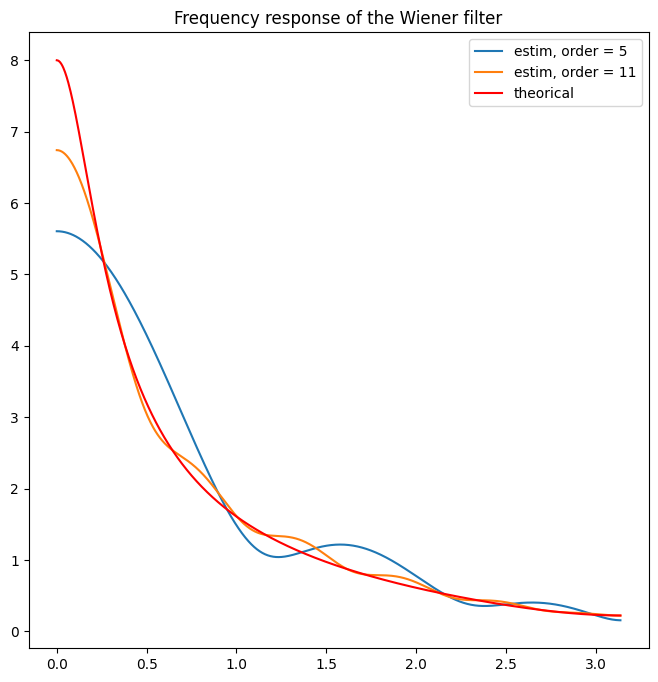

In [87]:
fig = plt.figure(figsize=(8, 8))

ax1 = fig.add_subplot(1, 1, 1)
ax1.plot(omega_5, np.abs(h_5), label = 'estim, order = 5') #np.abs pour enlever le warning des nombres complexes
ax1.plot(omega_11, np.abs(h_11), label = 'estim, order = 11')
ax1.plot(omega_theo, np.abs(h_theo), c = 'r', label = 'theorical')
ax1.set_title('Frequency response of the Wiener filter')
ax1.legend()

plt.show()

##### Ex2.3 filtering
- Estimate and display the noise $v_1[n]$ based on $v_2[n]$ and the Wiener filter designed

In [88]:
v1_hat_5 = signal.lfilter(w_5, 1, v2)
v1_hat_11 = signal.lfilter(w_11, 1, v2)

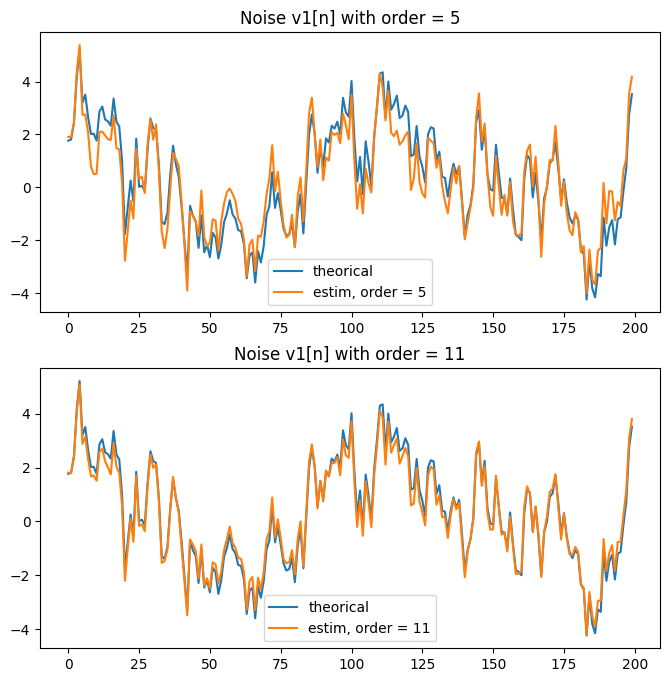

In [89]:
fig = plt.figure(figsize=(8, 8))

ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(v1, label = 'theorical')
ax1.plot(v1_hat_5, label = 'estim, order = 5')
ax1.set_title('Noise v1[n] with order = 5')
ax1.legend()

ax2 = fig.add_subplot(2, 1, 2)
ax2.plot(v1, label = 'theorical')
ax2.plot(v1_hat_11, label = 'estim, order = 11')
ax2.set_title('Noise v1[n] with order = 11')
ax2.legend()

plt.show()

##### Ex2.4 Signal reconstruction
Finally, the estimated noise can be removed from the measured signal.

- Compute and display the reconstructed signal
- Compute and display the approximation error

In [90]:
dhat_5 = x - v1_hat_5
dhat_11 = x - v1_hat_11

e_initial = d - x         # Erreur avant filtrage (le bruit v1 de base)
e_5       = d - dhat_5    # Résidu de bruit après filtre M=5
e_11      = d - dhat_11   # Résidu de bruit après filtre M=11

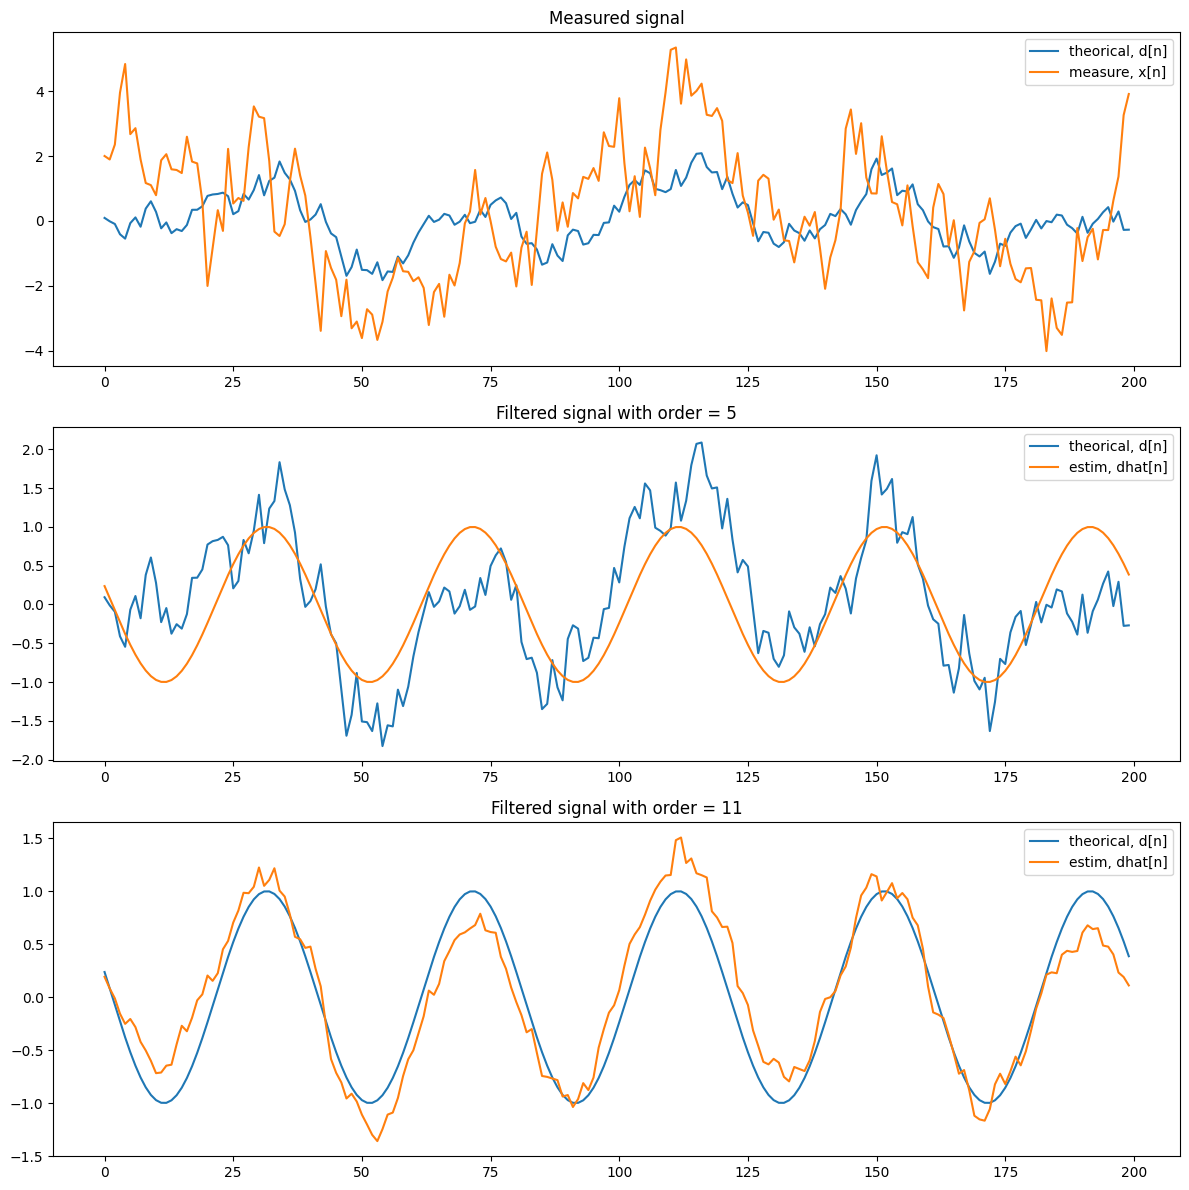

In [91]:
fig = plt.figure(figsize=(12, 12))


ax1 = fig.add_subplot(3, 1, 1)
ax1.plot(dhat_5, label = 'theorical, d[n]')
ax1.plot(x, label = 'measure, x[n]')
ax1.set_title('Measured signal')
ax1.legend()
fig.tight_layout()

ax2 = fig.add_subplot(3, 1, 2)
ax2.plot(dhat_5, label = 'theorical, d[n]')
ax2.plot(d, label = 'estim, dhat[n]')
ax2.set_title('Filtered signal with order = 5')
ax2.legend()
fig.tight_layout()

ax3 = fig.add_subplot(3, 1, 3)
ax3.plot(d, label = 'theorical, d[n]')
ax3.plot(dhat_11, label = 'estim, dhat[n]')
ax3.set_title('Filtered signal with order = 11')
ax3.legend()
fig.tight_layout()

plt.show()

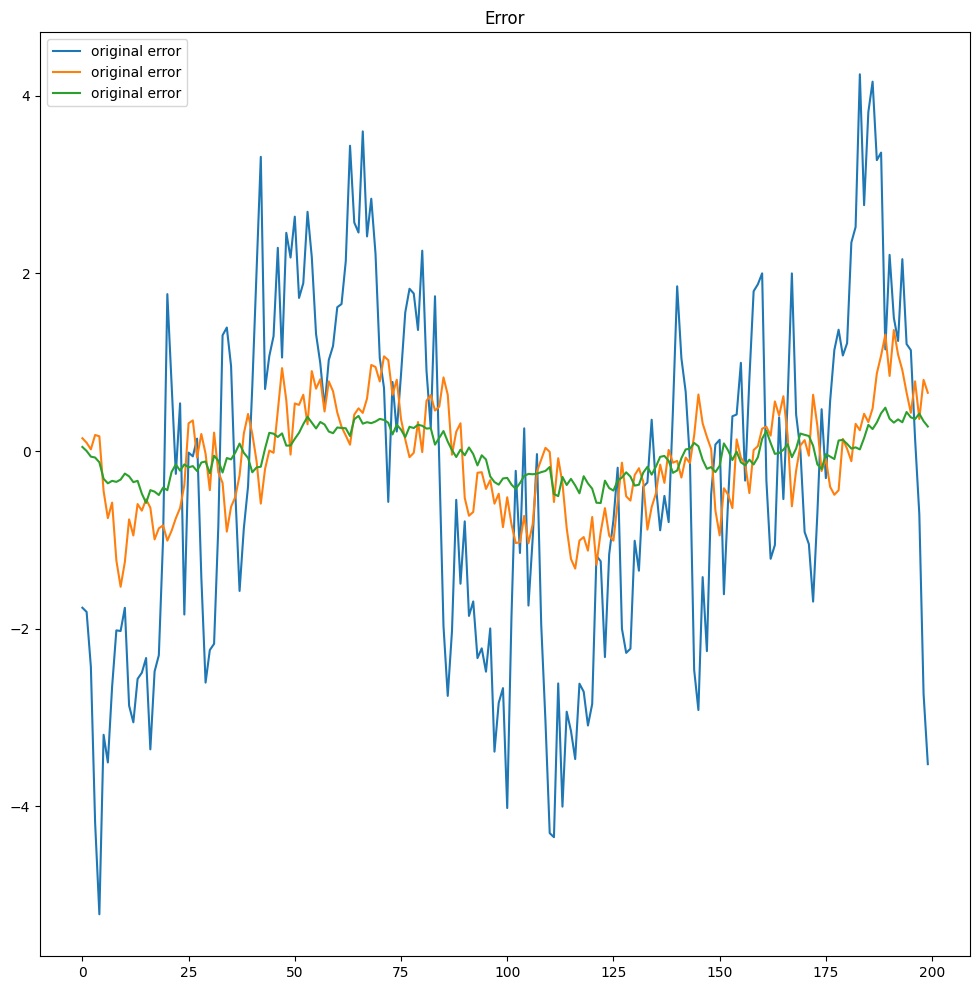

In [92]:
fig = plt.figure(figsize=(12, 12))
ax4 = fig.add_subplot(1, 1, 1)
ax4.plot(e_initial, label = 'original error')
ax4.plot(e_5, label = 'original error')
ax4.plot(e_11, label = 'original error')
ax4.set_title('Error')
ax4.legend()

plt.show()